# Evaluation and Deployment

This notebook evaluates the performance of the content-based homestay recommendation system and prepares the recommendation engine for deployment.

The notebook performs the following tasks:

1. Defines recommendation relevance criteria.
2. Evaluates recommendation quality using Precision@K.
3. Evaluates recommendation quality using Recall@K.
4. Evaluates ranking performance using NDCG@K.
5. Computes overall recommendation performance.
6. Saves trained recommendation components for deployment.
7. Exports files required for the Streamlit application.

The evaluation process helps measure how effectively the recommendation system identifies relevant homestays based on shared location characteristics, category, and amenities.

In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

from sklearn.metrics import ndcg_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity

from geopy.distance import geodesic

import re
import joblib

In [ ]:
# ==========================================
# LOAD PREPARED DATASET
# ==========================================

df = pd.read_csv(
    "../data/final/homestays_prepared.csv"
)

print(
    f"Dataset Shape: {df.shape}"
)

df = df.reset_index(drop=True)

df.head()

Dataset Shape: (811, 45)


,homestay_id,homestay_name,owner_name,category,district,block,village,owner_email,owner_mobile,google_name,...,mountain_view,room_service,bonfire_barbeque,pickup_dropoff_service,description,price_band,amenity_text,location_text,proximity_text,feature_text
0,1,Revere Homestay,Mr. Riwaj Pradhan,Silver,Kalimpong,Municipality,"8Th Mile, Kalimpong",riwajpradhan10@gmail.com,9800686780,Revere Homsetay,...,1,0,0,0,"Revere Homestay, located in 8th Mile, Kalimpon...",mid_range,wifi parking breakfast mountain_view,"Municipality 8Th Mile, Kalimpong",deolo_moderately_close durpin_very_close town_...,"Revere Homestay, located in 8th Mile, Kalimpon..."
1,2,Mansarover Homestay,Miss Tina Mani Gurung,Gold,Kalimpong,Municipality,"Chandralok, Kalimpong",santabgurung53@gmail.com,9932234895,Mansarover Homestay / Flora & Transport,...,0,1,1,0,"Mansarover Homestay, located in Chandralok, Ka...",premium,wifi parking breakfast room_service bonfire_ba...,"Municipality Chandralok, Kalimpong",deolo_moderately_close durpin_very_close town_...,"Mansarover Homestay, located in Chandralok, Ka..."
2,3,Bethany Homestay,Anupama Tamang,Silver,Kalimpong,Kalimpong I,Dr.Grahams Home Block B,wangchuck20199@gmial.com,8348993048,Bethany Homestay Kalimpong,...,1,0,0,0,"BETHANY HOMESTAY, located in Dr.GRAHAMS HOME B...",budget,breakfast mountain_view,Kalimpong I Dr.Grahams Home Block B,deolo_very_close durpin_moderately_close town_...,"BETHANY HOMESTAY, located in Dr.GRAHAMS HOME B..."
3,5,Bajarangi Homestay,Kamal Kumar Sharma,Silver,Kalimpong,Kalimpong I,Singi Samalbong Kalimpong,bajrangihomestay@gmail.com,8670450557,Bajrangi Homestay,...,1,1,0,0,"BAJARANGI HOMESTAY, located in SINGI SAMALBONG...",mid_range,parking breakfast mountain_view room_service,Kalimpong I Singi Samalbong Kalimpong,deolo_moderately_close durpin_moderately_close...,"BAJARANGI HOMESTAY, located in SINGI SAMALBONG..."
4,7,Relly View Homestay,Soma Sundas,Silver,Kalimpong,Kalimpong I,Dr.Grahams Homes Block B Kalimpong,somasundas55@gmail.com,9932095235,Kalimpong View Home Stay,...,0,0,1,1,Relly View Homestay is located in DR.GRAHAMS H...,mid_range,wifi breakfast bonfire_barbeque pickup_dropoff...,Kalimpong I Dr.Grahams Homes Block B Kalimpong,deolo_very_close durpin_moderately_close town_...,Relly View Homestay is located in DR.GRAHAMS H...


In [ ]:
# ==========================================
# RELEVANCE FUNCTION
# ==========================================

DISTANCE_THRESHOLD_KM = 2.0
RATING_THRESHOLD = 0.5

def _haversine_matrix(lats, lons):
    lat_r = np.radians(lats.values)
    lon_r = np.radians(lons.values)

    dlat = lat_r[None, :] - lat_r[:, None]
    dlon = lon_r[None, :] - lon_r[:, None]

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat_r[:, None]) * np.cos(lat_r[None, :]) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    EARTH_RADIUS_KM = 6371
    return EARTH_RADIUS_KM * c

_distance_matrix = _haversine_matrix(df["latitude"], df["longitude"])
_rating_matrix = np.abs(df["rating"].values[:, None] - df["rating"].values[None, :])

relevance_matrix = (
    (_distance_matrix <= DISTANCE_THRESHOLD_KM)
    & (_rating_matrix <= RATING_THRESHOLD)
)
np.fill_diagonal(relevance_matrix, False)  # a homestay is not "relevant" to itself


def is_relevant(
    source_row,
    target_row
):
    return relevance_matrix[source_row.name, target_row.name]

In [4]:
# ==========================================
# PRECISION@K
# ==========================================

def precision_at_k(
    source_index,
    recommended_indices,
    k=5
):

    source_row = df.iloc[source_index]

    recommendations = (
        recommended_indices[:k]
    )

    relevant_count = 0

    for idx in recommendations:

        target_row = df.iloc[idx]

        if is_relevant(
            source_row,
            target_row
        ):
            relevant_count += 1

    return (
        relevant_count / k
    )

In [5]:
# ==========================================
# RECALL@K
# ==========================================

def recall_at_k(
    source_index,
    recommended_indices,
    k=5
):

    source_row = df.iloc[source_index]

    all_relevant = []

    for idx in df.index:

        if idx == source_index:
            continue

        if is_relevant(
            source_row,
            df.iloc[idx]
        ):
            all_relevant.append(idx)

    total_relevant = len(all_relevant)

    if total_relevant == 0:
        return 0

    recommendations = (
        recommended_indices[:k]
    )

    retrieved_relevant = sum(

        1

        for idx in recommendations

        if idx in all_relevant

    )

    return (
        retrieved_relevant /
        total_relevant
    )

In [6]:
# ==========================================
# NDCG@K
# ==========================================

def ndcg_at_k(
    source_index,
    recommended_indices,
    k=5
):

    source_row = df.iloc[source_index]

    y_true = []
    y_score = []

    for rank, idx in enumerate(
        recommended_indices[:k]
    ):

        target_row = df.iloc[idx]

        relevance = int(

            is_relevant(
                source_row,
                target_row
            )

        )

        y_true.append(
            relevance
        )

        y_score.append(
            k - rank
        )

    return ndcg_score(
        [y_true],
        [y_score]
    )

In [7]:
# ==========================================
# F1@K
# ==========================================
# Harmonic mean of precision and recall -- penalizes imbalance between
# the two rather than just averaging them, so a model with high
# precision but low recall (or vice versa) doesn't get an inflated
# score.

def f1_at_k(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

In [ ]:
# ==========================================
# BUILD TF-IDF + SIMILARITY MATRIX (self-contained)
# ==========================================

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"wi[\s-]*fi", "wifi", text)
    text = re.sub(r"drop[\s-]*off", "dropoff", text)
    text = re.sub(r"pick[\s-]*up", "pickup", text)
    return text

DOMAIN_STOP_WORDS = [
    "including", "key", "locations", "location", "offers", "offering",
    "provides", "providing", "features", "featuring", "enjoy", "ensuring",
    "ensures", "convenient", "reliable", "situated", "nestled", "guests",
    "stay", "homestay", "kalimpong", "close", "far", "moderately", "rated",
]
custom_stop_words = list(ENGLISH_STOP_WORDS) + DOMAIN_STOP_WORDS

tfidf = TfidfVectorizer(
    stop_words=custom_stop_words,
    preprocessor=normalize_text,
)

tfidf_matrix = tfidf.fit_transform(df["feature_text"])

similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (811, 811)


In [9]:
# ==========================================
# RECOMMEND HOMESTAYS
# ==========================================

def recommend_homestays(
    homestay_index,
    top_n=5
):

    similarity_scores = list(
        enumerate(
            similarity_matrix[
                homestay_index
            ]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = (
        similarity_scores[1:top_n+1]
    )

    indices = [

        item[0]

        for item in similarity_scores

    ]

    return indices

In [10]:
# ==========================================
# BASELINE RECOMMENDER (random)
# ==========================================
# Without this, there's no way to know if the TF-IDF model's Precision/
# Recall/NDCG numbers are actually good, or just whatever any reasonable
# system would score on this data. Fixed seed for reproducibility.

_baseline_rng = np.random.default_rng(42)

def recommend_homestays_random(
    homestay_index,
    top_n=5
):
    candidates = [i for i in range(len(df)) if i != homestay_index]
    return list(_baseline_rng.choice(candidates, size=top_n, replace=False))

In [11]:
# ==========================================
# MODEL EVALUATION
# ==========================================

precision_scores = []
recall_scores = []
ndcg_scores = []
f1_scores = []

baseline_precision_scores = []
baseline_recall_scores = []
baseline_ndcg_scores = []
baseline_f1_scores = []

for idx in range(len(df)):

    recommendations = recommend_homestays(idx, top_n=5)

    p = precision_at_k(idx, recommendations, k=5)
    r = recall_at_k(idx, recommendations, k=5)

    precision_scores.append(p)
    recall_scores.append(r)
    ndcg_scores.append(ndcg_at_k(idx, recommendations, k=5))
    f1_scores.append(f1_at_k(p, r))

    baseline_recommendations = recommend_homestays_random(idx, top_n=5)

    bp = precision_at_k(idx, baseline_recommendations, k=5)
    br = recall_at_k(idx, baseline_recommendations, k=5)

    baseline_precision_scores.append(bp)
    baseline_recall_scores.append(br)
    baseline_ndcg_scores.append(ndcg_at_k(idx, baseline_recommendations, k=5))
    baseline_f1_scores.append(f1_at_k(bp, br))

In [12]:
# ==========================================
# FINAL RESULTS
# ==========================================

print("TF-IDF Content-Based Model:")
print(f"  Precision@5 : {np.mean(precision_scores):.4f}")
print(f"  Recall@5    : {np.mean(recall_scores):.4f}")
print(f"  F1@5        : {np.mean(f1_scores):.4f}")
print(f"  NDCG@5      : {np.mean(ndcg_scores):.4f}")

print("\nRandom Baseline:")
print(f"  Precision@5 : {np.mean(baseline_precision_scores):.4f}")
print(f"  Recall@5    : {np.mean(baseline_recall_scores):.4f}")
print(f"  F1@5        : {np.mean(baseline_f1_scores):.4f}")
print(f"  NDCG@5      : {np.mean(baseline_ndcg_scores):.4f}")

print("\nImprovement over random baseline:")
print(f"  Precision@5 : {np.mean(precision_scores) - np.mean(baseline_precision_scores):+.4f}")
print(f"  Recall@5    : {np.mean(recall_scores) - np.mean(baseline_recall_scores):+.4f}")
print(f"  F1@5        : {np.mean(f1_scores) - np.mean(baseline_f1_scores):+.4f}")
print(f"  NDCG@5      : {np.mean(ndcg_scores) - np.mean(baseline_ndcg_scores):+.4f}")

TF-IDF Content-Based Model:
  Precision@5 : 0.3120
  Recall@5    : 0.1017
  F1@5        : 0.1222
  NDCG@5      : 0.5156

Random Baseline:
  Precision@5 : 0.0311
  Recall@5    : 0.0052
  F1@5        : 0.0079
  NDCG@5      : 0.0882

Improvement over random baseline:
  Precision@5 : +0.2809
  Recall@5    : +0.0965
  F1@5        : +0.1143
  NDCG@5      : +0.4274


In [13]:
# ==========================================
# RELEVANT-HOMESTAY COUNT DIAGNOSTIC
# ==========================================
# Check this distribution against the new relevance definition -- if
# it's mostly 0, DISTANCE_THRESHOLD_KM/RATING_THRESHOLD are too strict.
# If most homestays are "relevant" to most others, they're too loose.

relevant_counts = []

for idx in range(len(df)):

    source_row = df.iloc[idx]

    count = 0

    for j in range(len(df)):

        if idx == j:
            continue

        if is_relevant(
            source_row,
            df.iloc[j]
        ):
            count += 1

    relevant_counts.append(count)

print(
    pd.Series(relevant_counts).describe()
)

count    811.000000
mean      27.277435
std       23.342447
min        0.000000
25%        6.000000
50%       20.000000
75%       46.000000
max       86.000000
dtype: float64


## Result Visualisations

In [15]:
# ==========================================
# VISUALISATION SETUP
# ==========================================

import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIGURES_DIR = "../data/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BAR_COLOR = "#4A6FA5"
MEAN_COLOR = "#C0392B"


def styled_hist(data, bins, title, xlabel, filename, mean_val=None):
    """Shared histogram style for the distribution figures in this notebook."""

    fig, ax = plt.subplots(figsize=(7, 4.2), dpi=200)

    ax.hist(data, bins=bins, color=BAR_COLOR, edgecolor="white", linewidth=0.6)

    if mean_val is not None:
        ax.axvline(mean_val, color=MEAN_COLOR, linestyle="--", linewidth=1.6, label=f"Mean = {mean_val:.3f}")
        ax.legend(frameon=False, loc="upper right")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.set_ylabel("Number of homestays", fontsize=10.5)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)

    fig.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, filename), facecolor="white")
    plt.show()


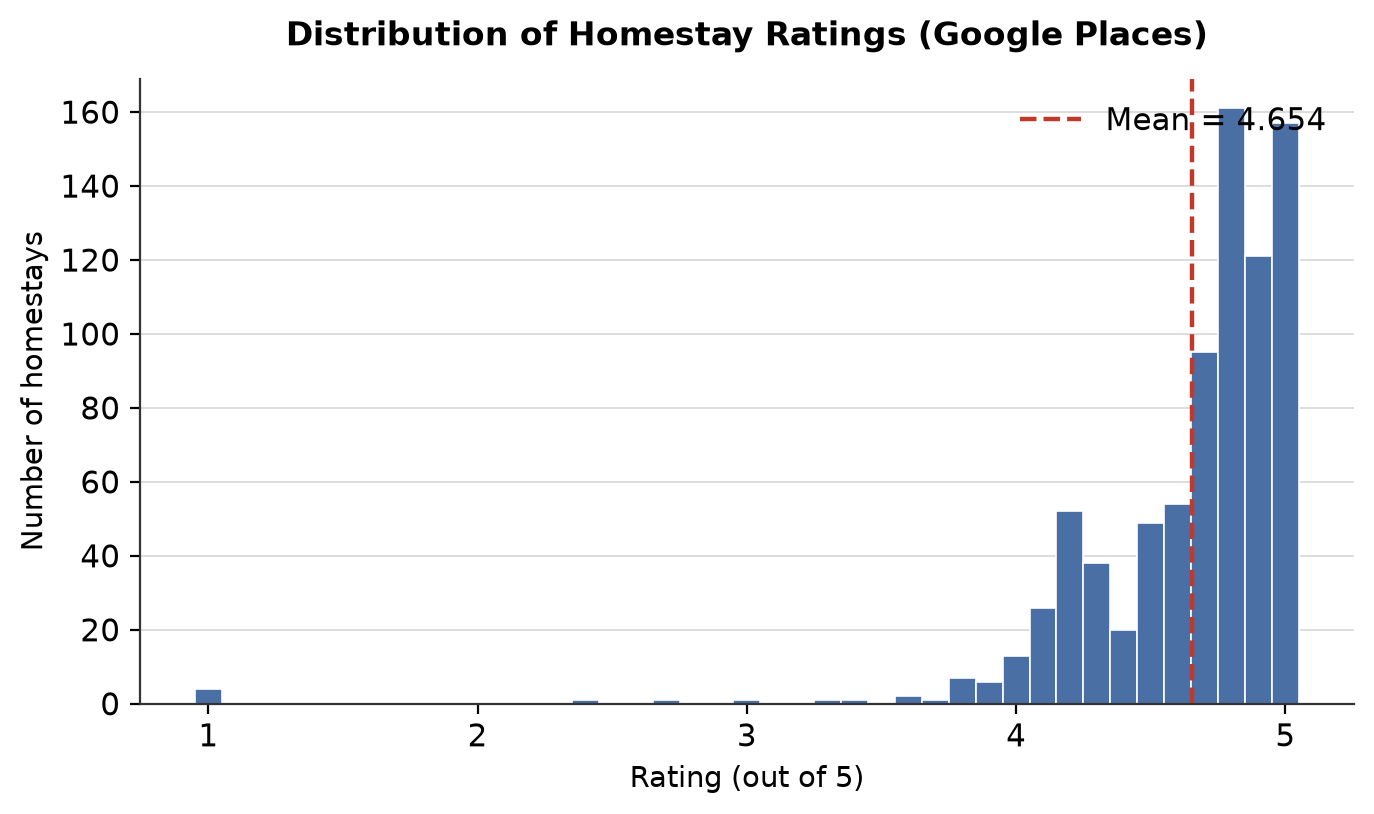

In [16]:
# ==========================================
# FIGURE: RATING DISTRIBUTION
# ==========================================

styled_hist(
    df["rating"],
    bins=np.arange(df["rating"].min() - 0.05, df["rating"].max() + 0.15, 0.1),
    title="Distribution of Homestay Ratings (Google Places)",
    xlabel="Rating (out of 5)",
    filename="rating_distribution.png",
    mean_val=float(df["rating"].mean()),
)


In [17]:
# ==========================================
# TOP-1 RECOMMENDATION SIMILARITY
# ==========================================
# The similarity score of each homestay's single best match -- distinct
# from Precision/Recall/NDCG below, since it reflects the strength of
# the content match itself rather than whether that match also happens
# to satisfy the independent relevance criterion (is_relevant above).

top1_similarities = []

for idx in range(len(df)):
    top_recommendation = recommend_homestays(idx, top_n=1)[0]
    top1_similarities.append(similarity_matrix[idx, top_recommendation])


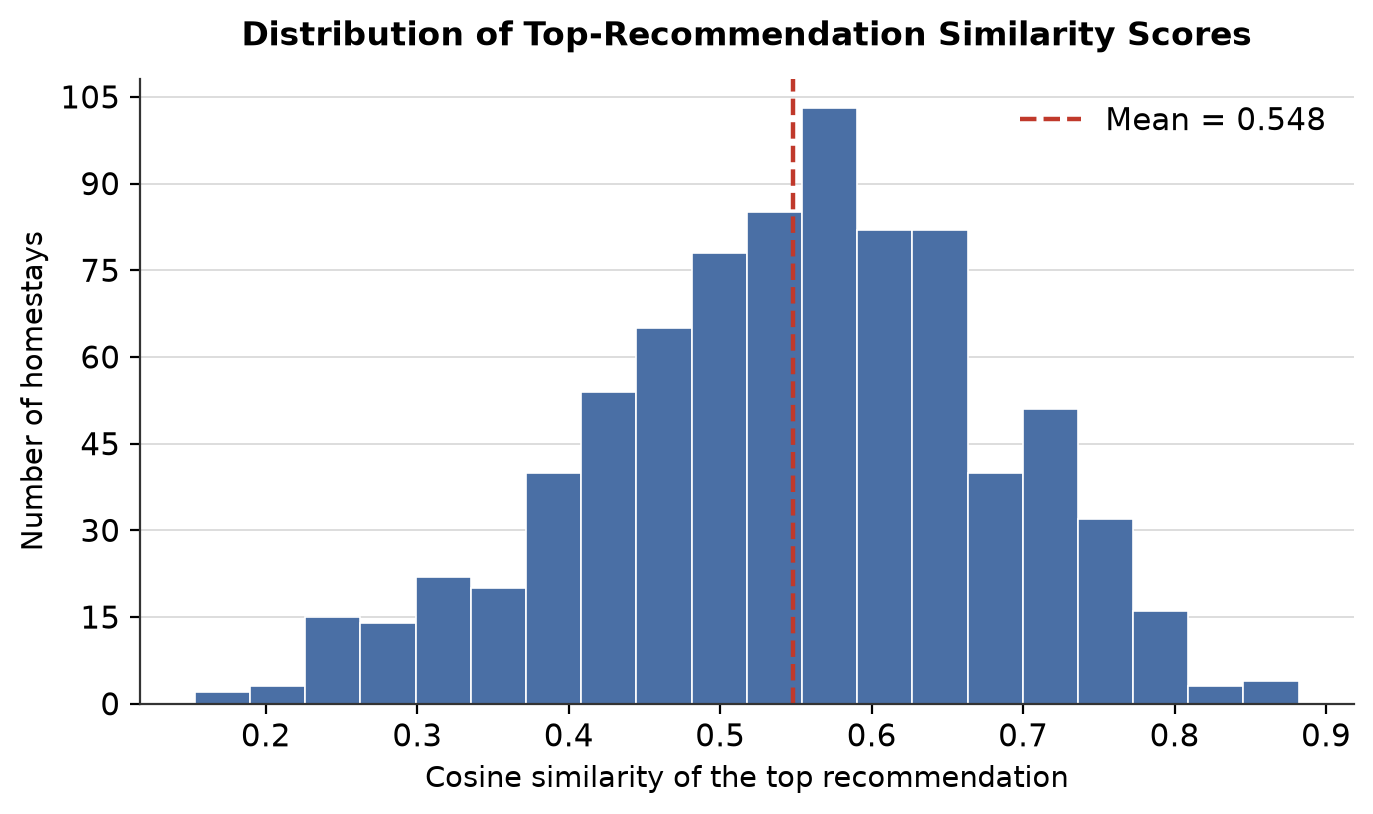

In [18]:
# ==========================================
# FIGURE: TOP-RECOMMENDATION SIMILARITY DISTRIBUTION
# ==========================================

styled_hist(
    top1_similarities,
    bins=20,
    title="Distribution of Top-Recommendation Similarity Scores",
    xlabel="Cosine similarity of the top recommendation",
    filename="similarity_distribution.png",
    mean_val=float(np.mean(top1_similarities)),
)


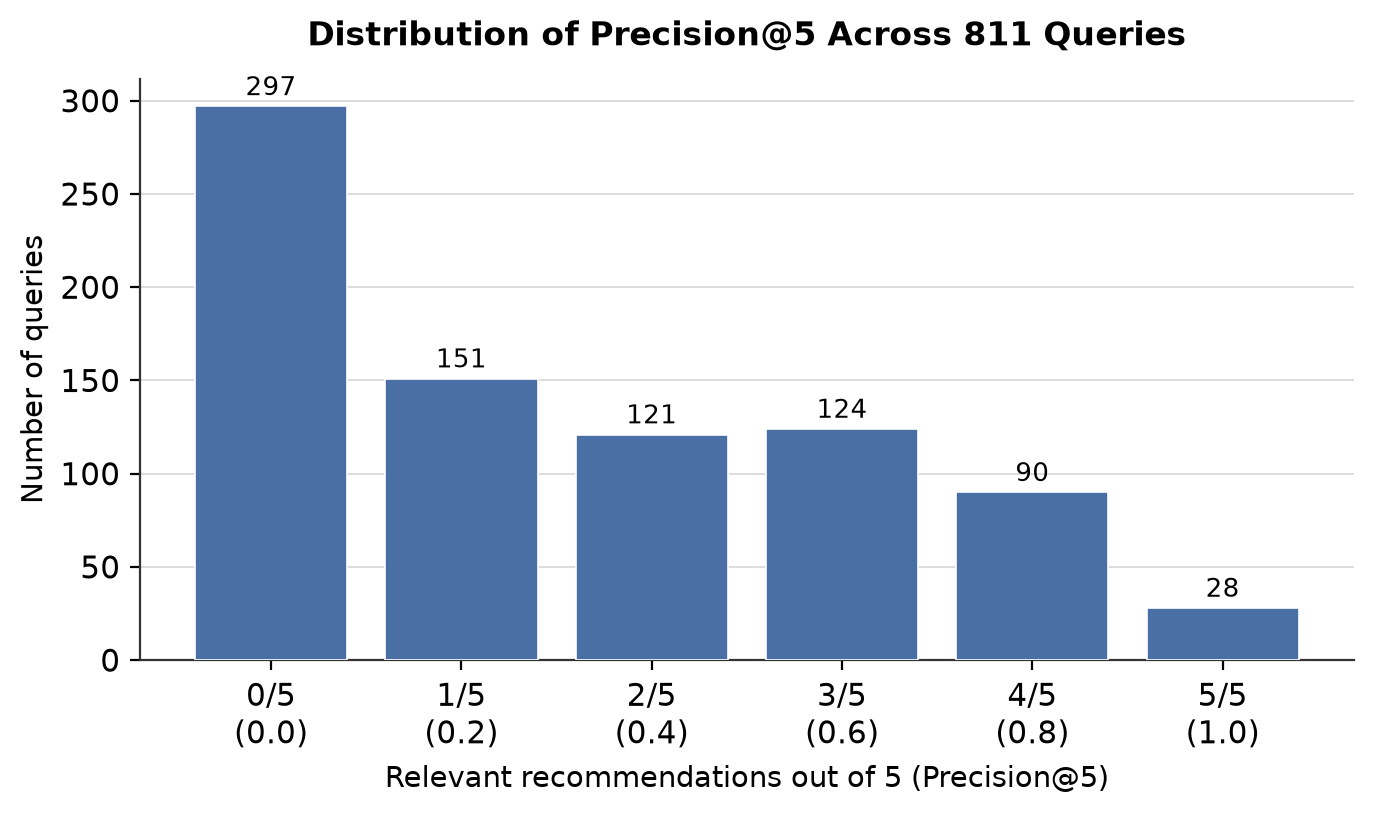

0/5\n(0.0)    297
1/5\n(0.2)    151
2/5\n(0.4)    121
3/5\n(0.6)    124
4/5\n(0.8)     90
5/5\n(1.0)     28
Name: queries, dtype: int64


In [19]:
# ==========================================
# FIGURE: PRECISION@5 DISTRIBUTION
# ==========================================
# Precision@5 only takes values in {0, 0.2, 0.4, 0.6, 0.8, 1.0}, since
# each query returns exactly 5 recommendations, so this is a bar chart
# of exact counts rather than a continuous histogram.

precision_labels = ["0/5\n(0.0)", "1/5\n(0.2)", "2/5\n(0.4)", "3/5\n(0.6)", "4/5\n(0.8)", "5/5\n(1.0)"]
precision_counts = [
    sum(1 for p in precision_scores if round(p, 1) == round(k / 5, 1))
    for k in range(6)
]

fig, ax = plt.subplots(figsize=(7, 4.2), dpi=200)

bars = ax.bar(precision_labels, precision_counts, color=BAR_COLOR, edgecolor="white", linewidth=0.6, zorder=3)

for bar, count in zip(bars, precision_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 6, str(count), ha="center", fontsize=9.5)

ax.set_title("Distribution of Precision@5 Across 811 Queries", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Relevant recommendations out of 5 (Precision@5)", fontsize=10.5)
ax.set_ylabel("Number of queries", fontsize=10.5)
ax.grid(axis="y", color="#dddddd", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "precision_at_5_distribution.png"), facecolor="white")
plt.show()

print(pd.Series(precision_counts, index=precision_labels, name="queries"))


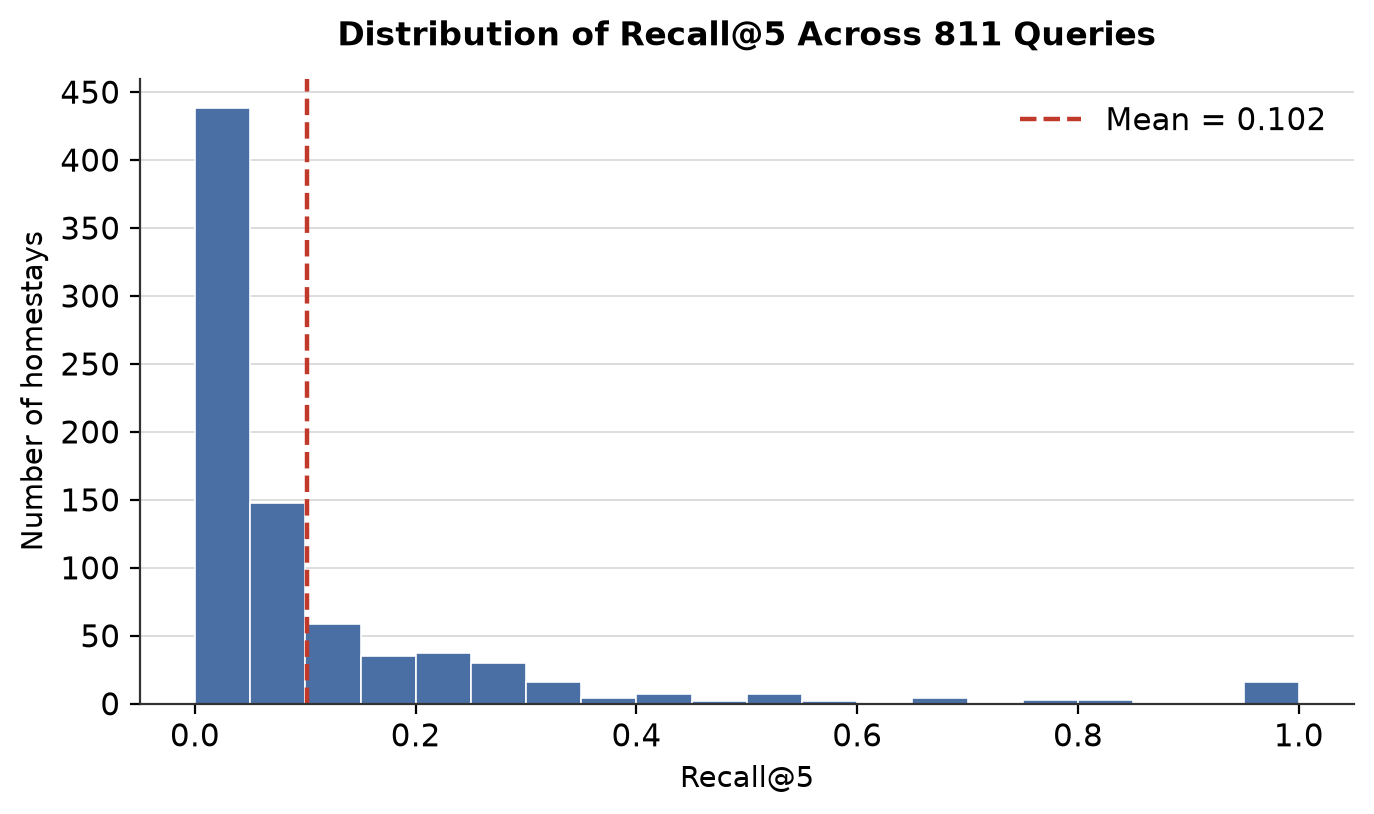

In [20]:
# ==========================================
# FIGURE: RECALL@5 DISTRIBUTION
# ==========================================

styled_hist(
    recall_scores,
    bins=np.arange(0, 1.05, 0.05),
    title="Distribution of Recall@5 Across 811 Queries",
    xlabel="Recall@5",
    filename="recall_at_5_distribution.png",
    mean_val=float(np.mean(recall_scores)),
)


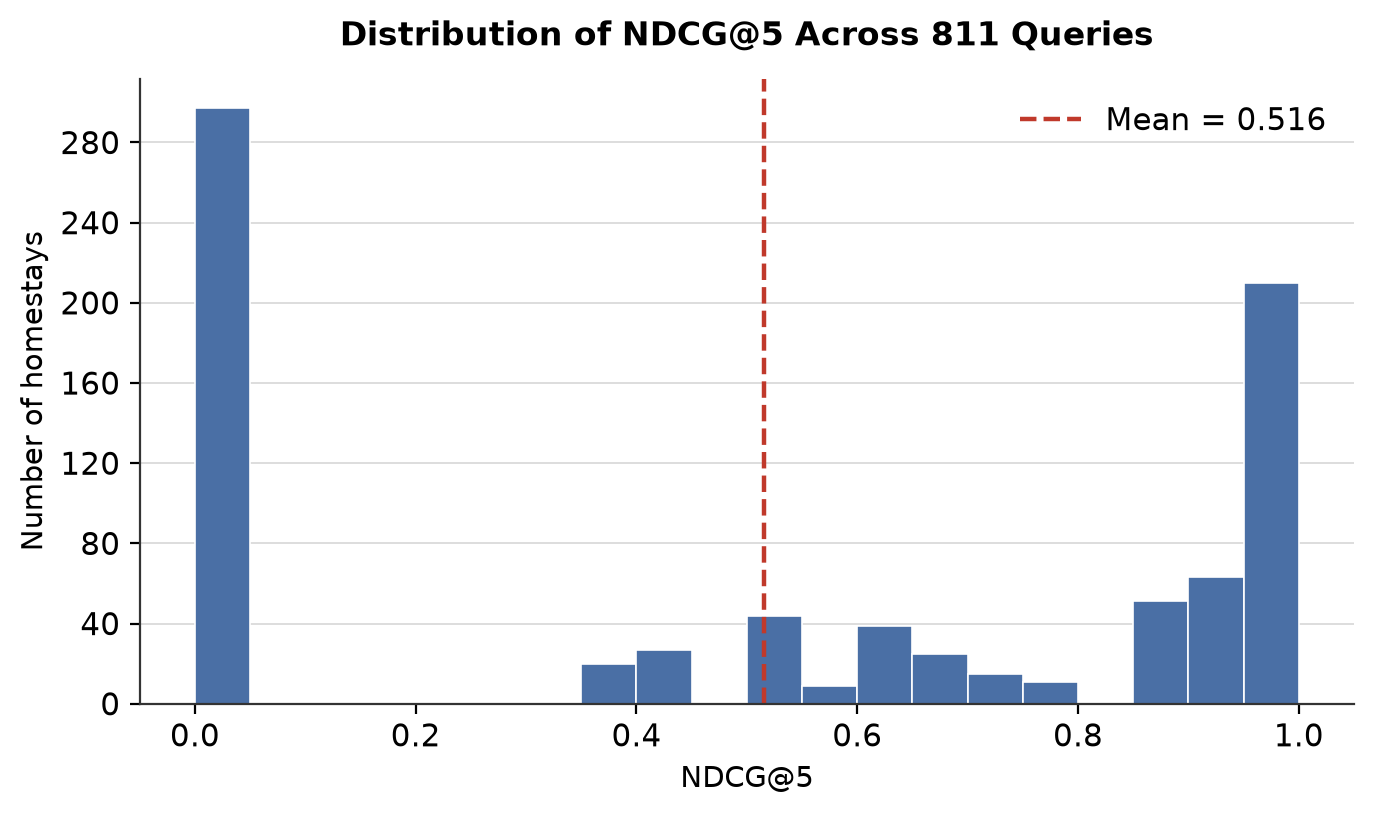

In [21]:
# ==========================================
# FIGURE: NDCG@5 DISTRIBUTION
# ==========================================

styled_hist(
    ndcg_scores,
    bins=np.arange(0, 1.05, 0.05),
    title="Distribution of NDCG@5 Across 811 Queries",
    xlabel="NDCG@5",
    filename="ndcg_at_5_distribution.png",
    mean_val=float(np.mean(ndcg_scores)),
)
